# EV Fleet Forecast — Spain 2027
**IE Sustainability Datathon March 2026 — Iberdrola**

This notebook produces the **`total_ev_projected_2027`** figure required in File 1 (Global Network KPIs).

It fits and compares four time-series forecasting models against monthly EV registration data from Spain's DGT (2015–2024), selects the best performer, and projects the cumulative EV fleet to December 2027.

**Models evaluated:**
| # | Model | AIC/BIC |
|---|-------|--------|
| 1 | ARIMA | ✓ |
| 2 | SARIMA | ✓ |
| 3 | Holt-Winters ETS | ✓ |
| 4 | Prophet | — (RMSE/MAPE/MAE only) |

**Evaluation metrics:** RMSE, MAPE, MAE, AIC, BIC  
**EV scope:** BEV + PHEV + REEV + FCEV (all plug-in vehicles — excludes HEV which requires no external charging)

**Data source:** DGT Microdatos de Matriculaciones (datos.gob.es forked repository)


## 0. Install Dependencies

In [ ]:
# Run this cell only if dependencies are missing (e.g. on Google Colab)
# !pip install -q pmdarima prophet statsmodels pyarrow pandas matplotlib seaborn scikit-learn

## 1. Imports & Configuration

In [2]:
import os
import warnings
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet

warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
sns.set_palette('colorblind')

# ─── Path configuration ───────────────────────────────────────────────────────
# Adjust PARQUET_DIR if running from a different working directory or on Colab
REPO_ROOT     = os.path.abspath(os.path.join(os.getcwd(), '..'))
PARQUET_DIR   = os.path.join(REPO_ROOT, 'mobility_electric_routes', 'Codigo', 'Data', 'parquet')
OUTPUT_DIR    = os.path.join(REPO_ROOT, 'notebooks', 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print(f'Parquet directory : {PARQUET_DIR}')
print(f'Output directory  : {OUTPUT_DIR}')
print(f'Parquet files found: {len(glob.glob(os.path.join(PARQUET_DIR, "*.parquet")))}')

Parquet directory : c:\Users\steve\OneDrive - IE University\Term 2\DATATHON_2\Iberdrola\SpanishElecticGrid\mobility_electric_routes\Codigo\Data\parquet
Output directory  : c:\Users\steve\OneDrive - IE University\Term 2\DATATHON_2\Iberdrola\SpanishElecticGrid\notebooks\outputs
Parquet files found: 108


## 2. Data Loading

Each parquet file covers one calendar month (`YYYY_MM.parquet`).  
Year and month are extracted from the filename — no additional date column is needed.

**EV classification** uses the `CATEGORÍA_VEHÍCULO_ELÉCTRICO` column:
- **BEV** — Battery Electric Vehicle (pure EV)
- **PHEV** — Plug-in Hybrid (requires external charging)
- **REEV** — Range-Extended EV (requires external charging)
- **FCEV** — Fuel Cell EV

HEV (standard hybrid) is excluded as it does not require public charging infrastructure.

In [3]:
EV_CATEGORIES = ['BEV', 'PHEV', 'REEV', 'FCEV']
CATEGORIA_COL = 'CATEGORÍA_VEHÍCULO_ELÉCTRICO'

records = []
parquet_files = sorted(glob.glob(os.path.join(PARQUET_DIR, '*.parquet')))

for path in parquet_files:
    fname = os.path.basename(path)          # e.g. '2023_01.parquet'
    year, month = fname.replace('.parquet', '').split('_')
    year, month = int(year), int(month)

    df = pd.read_parquet(path)

    # Normalise column name (encoding may vary across environments)
    cat_col = next((c for c in df.columns if 'CTRICO' in c or 'CTRICA' in c or 'ECTRICO' in c), None)
    if cat_col is None:
        continue

    total        = len(df)
    ev_mask      = df[cat_col].isin(EV_CATEGORIES)
    ev_count     = ev_mask.sum()
    bev_count    = (df[cat_col] == 'BEV').sum()
    phev_count   = (df[cat_col] == 'PHEV').sum()

    records.append({
        'year'        : year,
        'month'       : month,
        'date'        : pd.Timestamp(year=year, month=month, day=1),
        'total_reg'   : total,
        'ev_reg'      : ev_count,
        'bev_reg'     : bev_count,
        'phev_reg'    : phev_count,
    })

monthly = pd.DataFrame(records).sort_values('date').reset_index(drop=True)
monthly.set_index('date', inplace=True)

print(f'Period covered  : {monthly.index.min().strftime("%b %Y")} → {monthly.index.max().strftime("%b %Y")}')
print(f'Total months    : {len(monthly)}')
print(f'Total EV reg.   : {monthly["ev_reg"].sum():,}')
print()
print(monthly[['total_reg', 'ev_reg', 'bev_reg', 'phev_reg']].tail(12))

Period covered  : Jan 2015 → Dec 2023
Total months    : 108
Total EV reg.   : 460,199

            total_reg  ev_reg  bev_reg  phev_reg
date                                            
2023-01-01     107493    9035     4784      4237
2023-02-01     118991   10189     5228      4951
2023-03-01     156309   12852     6644      6193
2023-04-01     120571    9934     5406      4514
2023-05-01     150535   13409     7160      6244
2023-06-01     162334   14517     7828      6677
2023-07-01     138418   11179     5761      5399
2023-08-01      99791    9091     5478      3607
2023-09-01     112726   10431     5642      4781
2023-10-01     141046   13860     8115      5739
2023-11-01     134203   14471     8432      6025
2023-12-01     127659   14775     7772      6994


## 3. Exploratory Analysis

### 3.1 Monthly EV Registrations Over Time

Before fitting any model, we need to **understand the shape and behaviour of the data** — how many plug-in vehicles are being registered each month in Spain, how that has evolved since 2015, and whether there are clear seasonal or growth patterns a model needs to capture.

The chart below plots two lines:
- **Total plug-in** — every vehicle that requires an external charging point (BEV + PHEV + REEV + FCEV)
- **BEV only** — pure battery-electric vehicles with no combustion engine at all

And a second panel showing the **EV market share** — what percentage of all new car registrations that month were plug-in EVs.

---

#### What do the EV type acronyms mean?

| Code | Full name | How it works | Needs public charging? |
|------|-----------|-------------|----------------------|
| **BEV** | Battery Electric Vehicle | Runs 100% on a battery. No combustion engine. Must be plugged in to recharge. | Yes — fully dependent on it |
| **PHEV** | Plug-in Hybrid Electric Vehicle | Has both a battery and a petrol/diesel engine. Can be charged externally and can also run on fuel. Typically 40–80 km of electric range. | Yes — to use electric mode |
| **REEV** | Range-Extended Electric Vehicle | Runs primarily on battery but carries a small combustion engine that acts only as a generator to extend range — it never drives the wheels directly. | Yes |
| **FCEV** | Fuel Cell Electric Vehicle | Uses hydrogen fuel cells to generate electricity on board. No plug-in charging — refuels with hydrogen. Very rare in Spain. | No (hydrogen stations) |
| *HEV* | *(Hybrid Electric Vehicle)* | *Battery charged only by regenerative braking and the engine — cannot be plugged in. Excluded from this analysis.* | *No* |

> **Why exclude HEV?** A hybrid like the Toyota Yaris HEV recharges itself while driving — it never needs a public charger. Including it would inflate our demand figures without adding any real need for charging infrastructure.

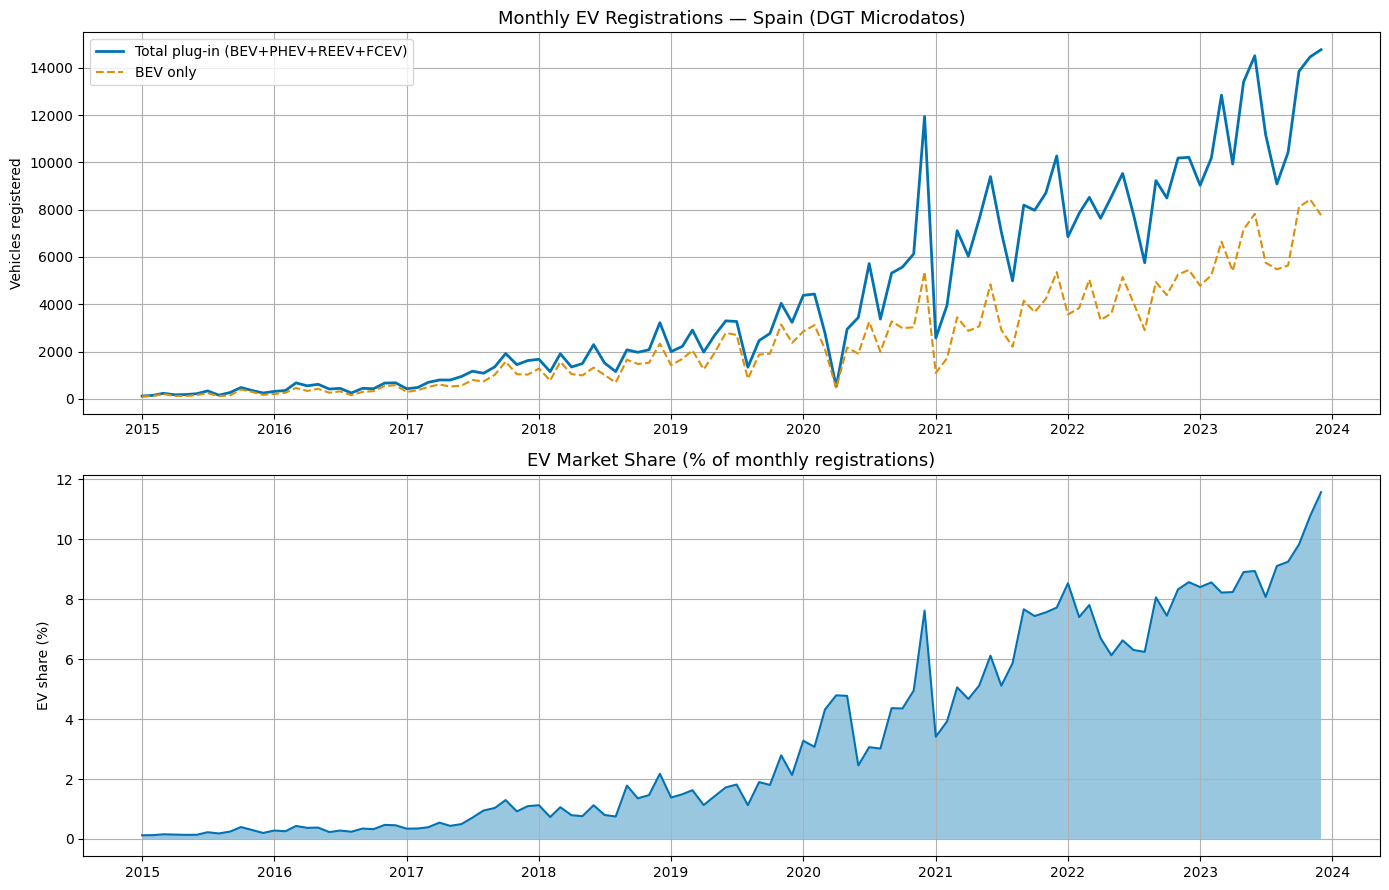

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# — Top: absolute monthly registrations
ax = axes[0]
ax.plot(monthly.index, monthly['ev_reg'],  label='Total plug-in (BEV+PHEV+REEV+FCEV)', lw=2)
ax.plot(monthly.index, monthly['bev_reg'], label='BEV only', lw=1.5, linestyle='--')
ax.set_title('Monthly EV Registrations — Spain (DGT Microdatos)', fontsize=13)
ax.set_ylabel('Vehicles registered')
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

# — Bottom: EV share of total registrations
ax2 = axes[1]
monthly['ev_share'] = monthly['ev_reg'] / monthly['total_reg'] * 100
ax2.fill_between(monthly.index, monthly['ev_share'], alpha=0.4)
ax2.plot(monthly.index, monthly['ev_share'], lw=1.5)
ax2.set_title('EV Market Share (% of monthly registrations)', fontsize=13)
ax2.set_ylabel('EV share (%)')
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ev_registrations_eda.png'), dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Annual EV Registrations by Type

Zooming out from monthly noise to an annual view lets us see three things clearly:
1. **How fast the overall EV market is growing year on year**
2. **How the mix between BEV and PHEV is shifting** — BEV steadily taking share from PHEV
3. **Whether growth is accelerating or plateauing** — relevant for choosing a trend model

The chart uses **stacked bars** so the height of each bar = total plug-in registrations that year, while the colour split shows the BEV vs PHEV composition. YoY growth refers to the total plug-in count.

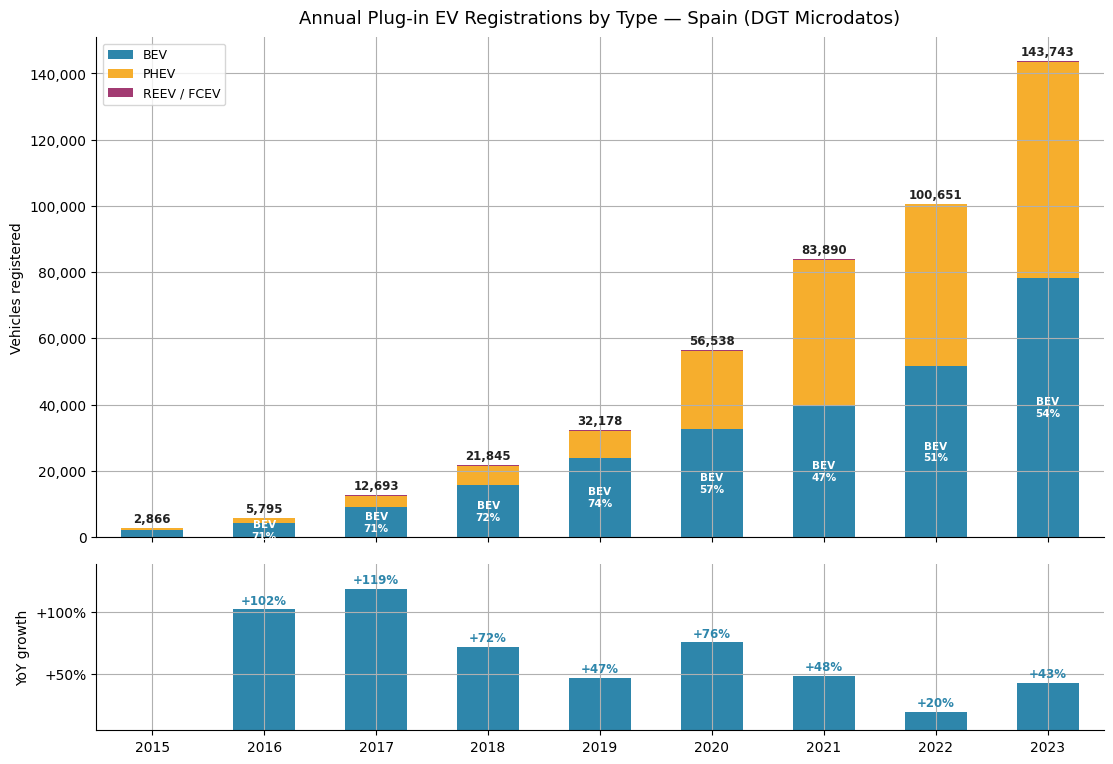

      ev_reg  bev_reg  phev_reg  ev_share  yoy_growth
year                                                 
2015    2866     2145       668  0.196977         NaN
2016    5795     4113      1525  0.341462  102.198186
2017   12693     9000      3350  0.698207  119.033650
2018   21845    15634      5823  1.121084   72.102734
2019   32178    23954      7932  1.690072   47.301442
2020   56538    32488     23839  4.087230   75.703897
2021   83890    39559     44139  5.850947   48.378082
2022  100651    51547     48907  7.299893   19.979735
2023  143743    78250     65361  9.155162   42.813286


In [5]:
annual = monthly.groupby('year')[['ev_reg', 'bev_reg', 'phev_reg', 'total_reg']].sum()
annual['other_reg']  = annual['ev_reg'] - annual['bev_reg'] - annual['phev_reg']  # REEV + FCEV
annual['ev_share']   = annual['ev_reg'] / annual['total_reg'] * 100
annual['yoy_growth'] = annual['ev_reg'].pct_change() * 100

years = annual.index.astype(str)
x     = np.arange(len(annual))
BAR_W = 0.55

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 9), gridspec_kw={'height_ratios': [3, 1]})
fig.subplots_adjust(hspace=0.08)

# ── Top panel: stacked bars ──────────────────────────────────────────────────
b_bev   = ax1.bar(x, annual['bev_reg'],   BAR_W, label='BEV',          color='#2E86AB')
b_phev  = ax1.bar(x, annual['phev_reg'],  BAR_W, label='PHEV',         color='#F6AE2D', bottom=annual['bev_reg'])
b_other = ax1.bar(x, annual['other_reg'], BAR_W, label='REEV / FCEV',  color='#A23B72',
                  bottom=annual['bev_reg'] + annual['phev_reg'])

# Total value label on top of each stack
for i, (yr, row) in enumerate(annual.iterrows()):
    ax1.text(i, row['ev_reg'] + 800, f"{int(row['ev_reg']):,}",
             ha='center', va='bottom', fontsize=8.5, fontweight='bold', color='#222')

# BEV share label inside each BEV bar (only if bar is tall enough)
for i, (yr, row) in enumerate(annual.iterrows()):
    bev_share = row['bev_reg'] / row['ev_reg'] * 100 if row['ev_reg'] > 0 else 0
    if row['bev_reg'] > 3000:
        ax1.text(i, row['bev_reg'] / 2, f"BEV\n{bev_share:.0f}%",
                 ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')

ax1.set_title('Annual Plug-in EV Registrations by Type — Spain (DGT Microdatos)', fontsize=13, pad=10)
ax1.set_ylabel('Vehicles registered', fontsize=10)
ax1.set_xticks(x)
ax1.set_xticklabels([])          # hidden — shared with bottom panel
ax1.set_xlim(-0.5, len(x) - 0.5)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))
ax1.legend(loc='upper left', fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)

# ── Bottom panel: YoY growth bars ───────────────────────────────────────────
colors_yoy = ['#2E86AB' if v >= 0 else '#E84855' for v in annual['yoy_growth'].fillna(0)]
ax2.bar(x[1:], annual['yoy_growth'].iloc[1:], BAR_W, color=colors_yoy[1:])
ax2.axhline(0, color='#555', lw=0.8)

for i, val in enumerate(annual['yoy_growth'].iloc[1:]):
    ax2.text(i + 1, val + (2 if val >= 0 else -5),
             f'{val:+.0f}%', ha='center', va='bottom', fontsize=8.5, fontweight='bold',
             color='#2E86AB' if val >= 0 else '#E84855')

ax2.set_ylabel('YoY growth', fontsize=10)
ax2.set_xticks(x)
ax2.set_xticklabels(years, fontsize=10)
ax2.set_xlim(-0.5, len(x) - 0.5)
ax2.set_ylim(annual['yoy_growth'].min() - 15, annual['yoy_growth'].max() + 20)
ax2.spines[['top', 'right']].set_visible(False)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:+.0f}%'))

plt.savefig(os.path.join(OUTPUT_DIR, 'ev_annual_registrations.png'), dpi=150, bbox_inches='tight')
plt.show()

print(annual[['ev_reg', 'bev_reg', 'phev_reg', 'ev_share', 'yoy_growth']].to_string())

### 3.3 Stationarity Test (Augmented Dickey-Fuller)

Before fitting ARIMA or SARIMA, we need to check whether the series is **stationary** — meaning its statistical properties (mean, variance) don't change over time.

**Why does this matter?** ARIMA and SARIMA are built on the assumption that the series has been made stationary. If you feed a non-stationary series directly into ARIMA, the model will produce unreliable estimates because it can't distinguish a real signal from a drifting trend.

**What is the ADF test?** The Augmented Dickey-Fuller test checks for the presence of a **unit root** — the statistical signature of a non-stationary series. The null hypothesis is *"the series has a unit root (non-stationary)"*, so:
- **p-value < 0.05** → reject the null → series **is stationary** ✓
- **p-value ≥ 0.05** → fail to reject → series **is non-stationary** ✗

We test three versions of the series to understand how many differencing steps are needed:
1. **Raw** — the original monthly EV registration counts
2. **1st-order differenced** — the month-on-month *change* in registrations (removes trend)
3. **Seasonal differenced (lag-12)** — the year-on-year *change* for the same month (removes annual seasonality)

In [10]:
series = monthly['ev_reg'].asfreq('MS')  # monthly start frequency

def adf_report(s, label):
    result = adfuller(s.dropna())
    print(f'ADF Test — {label}')
    print(f'  Statistic : {result[0]:.4f}')
    print(f'  p-value   : {result[1]:.4f}  {"→ STATIONARY" if result[1] < 0.05 else "→ non-stationary"}')
    print()

adf_report(series, 'Raw EV registrations')
adf_report(series.diff(1), '1st-order differenced')
adf_report(series.diff(12), 'Seasonal differenced (lag-12)')

ADF Test — Raw EV registrations
  Statistic : 2.6915
  p-value   : 0.9991  → non-stationary

ADF Test — 1st-order differenced
  Statistic : -8.8730
  p-value   : 0.0000  → STATIONARY

ADF Test — Seasonal differenced (lag-12)
  Statistic : -2.0553
  p-value   : 0.2629  → non-stationary



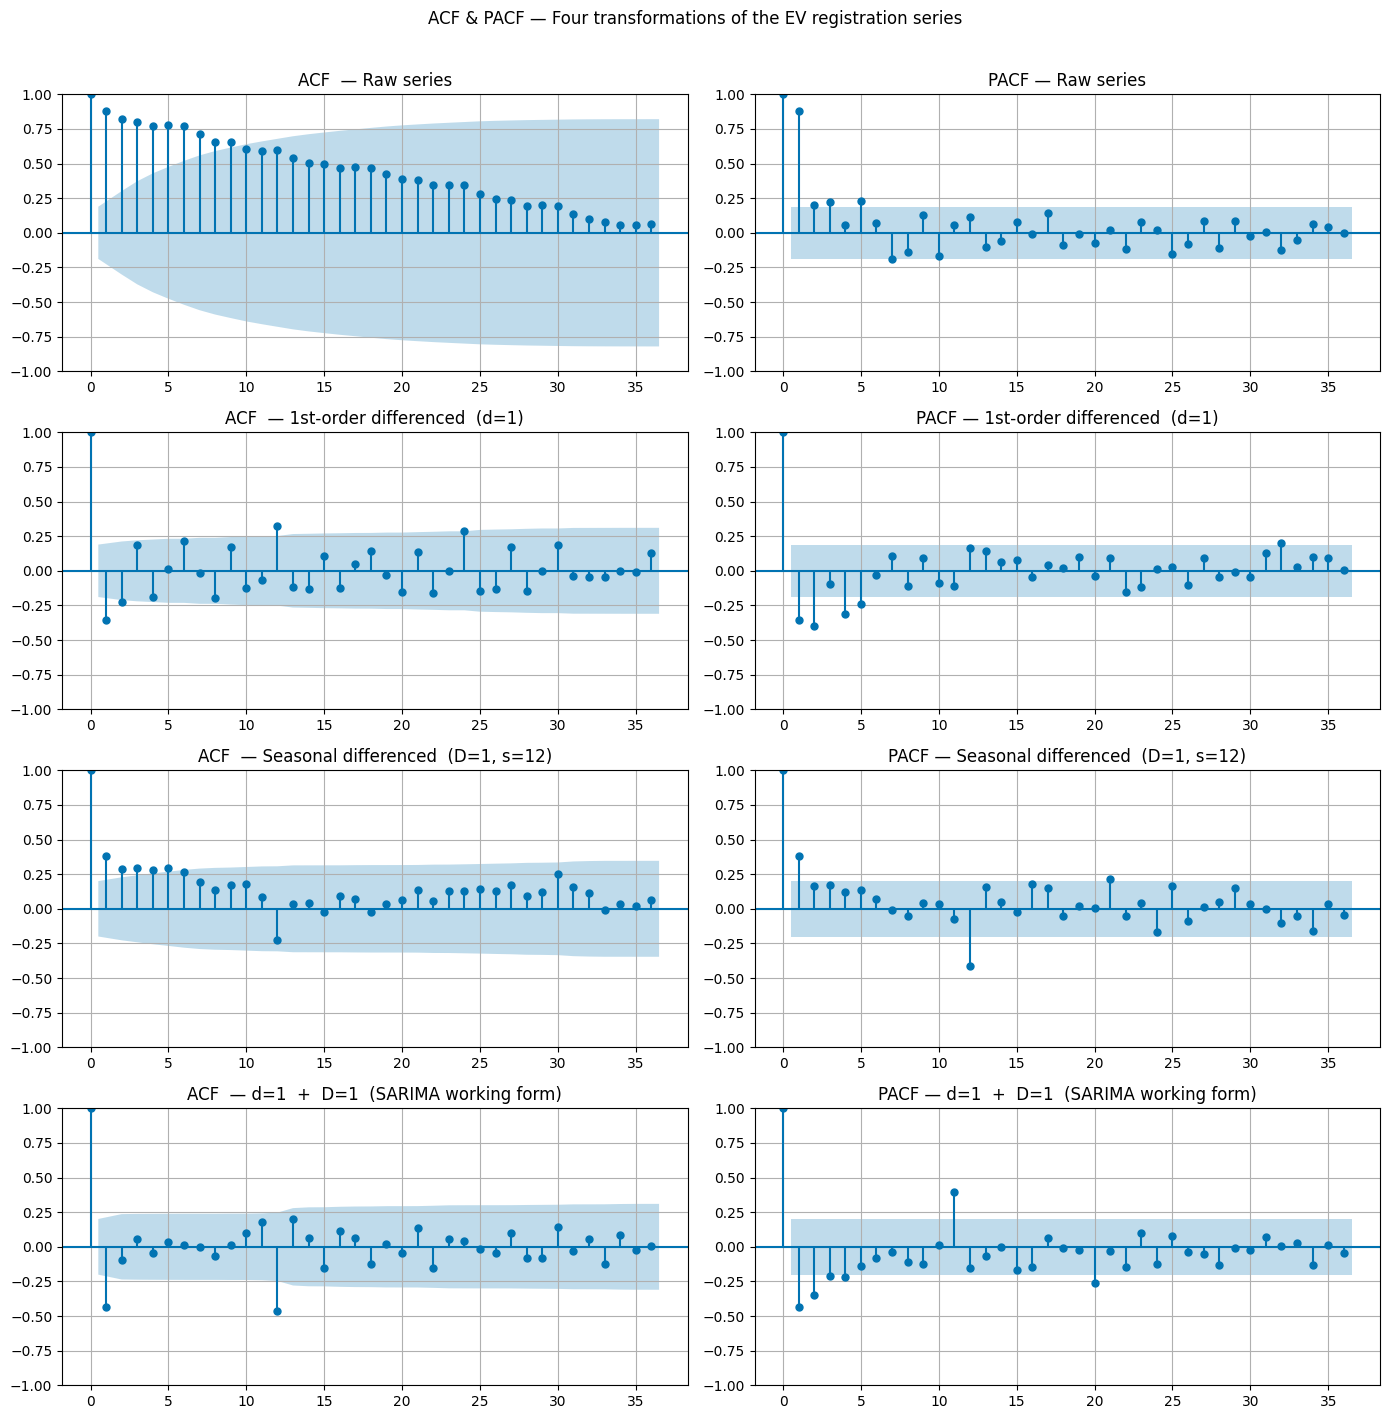

In [11]:
s_raw       = series                      # raw
s_d1        = series.diff(1)              # 1st-order diff   (removes trend)
s_D1        = series.diff(12)             # seasonal diff    (removes seasonality)
s_d1_D1     = series.diff(1).diff(12)    # both             (what SARIMA works on internally)

fig, axes = plt.subplots(4, 2, figsize=(14, 14))
fig.suptitle('ACF & PACF — Four transformations of the EV registration series', fontsize=12, y=1.01)

labels = [
    ('Raw series',                        s_raw),
    ('1st-order differenced  (d=1)',       s_d1),
    ('Seasonal differenced  (D=1, s=12)', s_D1),
    ('d=1  +  D=1  (SARIMA working form)',s_d1_D1),
]

for row, (label, s) in enumerate(labels):
    plot_acf( s.dropna(), lags=36, ax=axes[row, 0], title=f'ACF  — {label}',  alpha=0.05)
    plot_pacf(s.dropna(), lags=36, ax=axes[row, 1], title=f'PACF — {label}', alpha=0.05)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'acf_pacf_all.png'), dpi=150, bbox_inches='tight')
plt.show()

#### What are ACF and PACF, and how do we read them?

**ACF (Autocorrelation Function)** — measures how correlated the series is with its own past values at each lag. A spike at lag *k* means "the value today is correlated with the value *k* months ago."

**PACF (Partial Autocorrelation Function)** — same idea, but *removes* the effect of all intermediate lags. So a spike at lag 2 in the PACF means "there is a direct relationship between today and 2 months ago, even after accounting for lag 1."

The **shaded blue band** is the 95% confidence interval — spikes outside it are statistically significant. Spikes inside are noise.

---

> **On the p-value of 0.0000 for the 1st-order differenced series:** not suspicious at all. The ADF statistic of −8.87 is so far into the rejection region (1% critical value is −3.5) that the true p-value is around 10⁻¹⁴ — Python just rounds it to 0.0000. Think of it as a z-score of nearly 9. This is a strong, unambiguous result.

---

#### Reading the four rows

**Row 1 — Raw series:**
- **ACF:** Starts at ~1.0 and decays extremely slowly — still positive and significant past lag 25. This is the textbook signature of a trending, non-stationary series. The series has a very long "memory" because it never stops drifting upward.
- **PACF:** One massive spike at lag 1 (~0.9), then essentially zero after that. All the trend information is concentrated in a single one-month lag — once you account for last month's value, earlier months add nothing.

**Row 2 — 1st-order differenced (d=1):**
- **ACF:** Collapses immediately — a significant **negative spike at lag 1** (~−0.35), then most lags fall inside the confidence band. There is a small positive spike around lag 12 just outside the band — annual seasonality is still present but hasn't been fully removed. The negative lag-1 spike tells us an **MA(q=1)** term is needed.
- **PACF:** Large **negative spike at lag 1** (~−0.45) and a smaller one at lag 2 — consistent with an **AR(p=1 or 2)** component. Seasonal spikes at lags 12/24 mirror the ACF, confirming that D=1 is also required.

**Row 3 — Seasonal differenced only (D=1, s=12):**
- **ACF:** Positive autocorrelations at lags 1–4 are still clearly significant — the upward trend has *not* been removed. The ACF hasn't decayed to zero; it is still showing the slow-decline shape of a non-stationary series, just less extreme than the raw form. Seasonal differencing alone is not enough.
- **PACF:** A dominant spike at lag 1 and a notable **negative spike around lag 11–12** — the seasonal structure has been partially addressed but trend stationarity is still violated. This cross-validates the ADF p-value of 0.2629 from the stationarity test.

**Row 4 — d=1 + D=1 combined (SARIMA's working form):**
- **ACF:** Now the cleanest picture — a **significant negative spike at lag 1** (~−0.5) and then virtually everything else inside the confidence band. A very faint signal around lag 12–13 suggests residual seasonal MA structure (Q=1), but the series is broadly stationary.
- **PACF:** A **large positive spike at lag 1** (~0.75), a smaller negative one at lag 2, and a notable **negative spike around lag 11–12** — this is the seasonal AR fingerprint (P=1). After lag 12, the PACF is clean. This is the key diagnostic row: it tells us directly what terms SARIMA still needs once the data is fully prepared.

---

#### Model order summary from the plots

| Component | Diagnostic signal | Chosen order |
|-----------|------------------|-------------|
| Regular differencing | Raw ACF: very slow decay → non-stationary | **d = 1** |
| Seasonal differencing | d=1 ACF: spikes at lag 12/24 remain | **D = 1, s = 12** |
| AR order (p) | PACF d=1: spikes at lags 1–2, cuts off | **p = 1–2** |
| MA order (q) | ACF d=1 and ACF d=1+D=1: negative spike at lag 1, cuts off | **q = 1** |
| Seasonal AR (P) | PACF d=1+D=1: significant spike at lag 11–12 | **P = 1** |
| Seasonal MA (Q) | ACF d=1+D=1: faint spike at lag 12–13 | **Q = 1** |

These plots justify the orders **ARIMA(2,1,2)** and **SARIMA(1,1,1)(1,1,1,12)** used in the models below.

## 4. Train / Test Split (we're here now, continue after)

We hold out the last **12 months** (2024) as the test set.  
Training covers Jan 2015 – Dec 2023 (108 months).

In [13]:
TEST_MONTHS = 12

train = series.iloc[:-TEST_MONTHS]
test  = series.iloc[-TEST_MONTHS:]

print(f'Train: {train.index[0].strftime("%b %Y")} → {train.index[-1].strftime("%b %Y")}  ({len(train)} months)')
print(f'Test : {test.index[0].strftime("%b %Y")}  → {test.index[-1].strftime("%b %Y")}  ({len(test)} months)')

Train: Jan 2015 → Dec 2022  (96 months)
Test : Jan 2023  → Dec 2023  (12 months)


## 5. Evaluation Helper Functions

In [14]:
def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100

def evaluate(y_true, y_pred, model_name, aic=None, bic=None):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    mape_val = mape(y_true, y_pred)
    return {
        'Model'  : model_name,
        'RMSE'   : round(rmse, 1),
        'MAE'    : round(mae, 1),
        'MAPE %' : round(mape_val, 2),
        'AIC'    : round(aic, 1) if aic is not None else '—',
        'BIC'    : round(bic, 1) if bic is not None else '—',
    }

results = []   # collect metrics from all models
forecasts = {} # store test-period & future forecasts

## 6. Model 1 — ARIMA

**ARIMA(p, d, q)** — captures autoregressive, integrated, and moving-average components.  
We apply a log transformation to stabilise variance before fitting.

In [15]:
log_train = np.log1p(train)
log_test  = np.log1p(test)

# Order selected via ACF/PACF inspection: d=1 (non-stationary), p=2, q=2
ARIMA_ORDER = (2, 1, 2)

arima_model  = ARIMA(log_train, order=ARIMA_ORDER).fit()
arima_pred   = np.expm1(arima_model.forecast(steps=TEST_MONTHS))
arima_pred.index = test.index

print(arima_model.summary())
print(f'\nAIC: {arima_model.aic:.1f}  |  BIC: {arima_model.bic:.1f}')

results.append(evaluate(test, arima_pred, f'ARIMA{ARIMA_ORDER}', arima_model.aic, arima_model.bic))
forecasts['ARIMA'] = arima_pred
print('\nTest-period metrics:', results[-1])

                               SARIMAX Results                                
Dep. Variable:                 ev_reg   No. Observations:                   96
Model:                 ARIMA(2, 1, 2)   Log Likelihood                 -46.769
Date:                Mon, 16 Mar 2026   AIC                            103.538
Time:                        11:16:08   BIC                            116.307
Sample:                    01-01-2015   HQIC                           108.698
                         - 12-01-2022                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.8525      0.198     -4.313      0.000      -1.240      -0.465
ar.L2          0.1474      0.179      0.823      0.410      -0.204       0.498
ma.L1          0.3388      0.722      0.469      0.6

## 7. Model 2 — SARIMA

**SARIMA(p,d,q)(P,D,Q,s)** — extends ARIMA with seasonal components.  
Period `s=12` captures the annual seasonality of vehicle registrations (dip in August, peak in December).

In [16]:
SARIMA_ORDER         = (1, 1, 1)
SARIMA_SEASONAL_ORDER = (1, 1, 1, 12)

sarima_model = SARIMAX(
    log_train,
    order=SARIMA_ORDER,
    seasonal_order=SARIMA_SEASONAL_ORDER,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_pred = np.expm1(sarima_model.forecast(steps=TEST_MONTHS))
sarima_pred.index = test.index

print(sarima_model.summary())
print(f'\nAIC: {sarima_model.aic:.1f}  |  BIC: {sarima_model.bic:.1f}')

results.append(evaluate(test, sarima_pred, f'SARIMA{SARIMA_ORDER}x{SARIMA_SEASONAL_ORDER}', sarima_model.aic, sarima_model.bic))
forecasts['SARIMA'] = sarima_pred
print('\nTest-period metrics:', results[-1])

                                     SARIMAX Results                                      
Dep. Variable:                             ev_reg   No. Observations:                   96
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 -31.486
Date:                            Mon, 16 Mar 2026   AIC                             72.973
Time:                                    11:16:09   BIC                             84.143
Sample:                                01-01-2015   HQIC                            77.404
                                     - 12-01-2022                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2988      0.179      1.667      0.095      -0.052       0.650
ma.L1         -0.8581      0.146   

## 8. Model 3 — Holt-Winters ETS

**Triple Exponential Smoothing** with additive trend and multiplicative seasonality.  
Well-suited to series that grow exponentially with a stable seasonal pattern.

In [17]:
hw_model = ExponentialSmoothing(
    train,
    trend='add',
    seasonal='mul',
    seasonal_periods=12,
    initialization_method='estimated'
).fit(optimized=True)

hw_pred = hw_model.forecast(steps=TEST_MONTHS)
hw_pred.index = test.index

print(f'AIC: {hw_model.aic:.1f}  |  BIC: {hw_model.bic:.1f}')
print(f'Alpha (level): {hw_model.params["smoothing_level"]:.4f}')
print(f'Beta  (trend): {hw_model.params["smoothing_trend"]:.4f}')
print(f'Gamma (seas.) : {hw_model.params["smoothing_seasonal"]:.4f}')

results.append(evaluate(test, hw_pred, 'Holt-Winters (add+mul)', hw_model.aic, hw_model.bic))
forecasts['Holt-Winters'] = hw_pred
print('\nTest-period metrics:', results[-1])

AIC: 1333.3  |  BIC: 1374.3
Alpha (level): 0.2592
Beta  (trend): 0.2592
Gamma (seas.) : 0.0000

Test-period metrics: {'Model': 'Holt-Winters (add+mul)', 'RMSE': np.float64(4373.4), 'MAE': 4193.0, 'MAPE %': np.float64(34.55), 'AIC': np.float64(1333.3), 'BIC': np.float64(1374.3)}


## 9. Model 4 — Prophet

Facebook's **Prophet** decomposes the series into trend + seasonality + holidays.  
It is robust to missing data and structural breaks.  
> Note: Prophet does not output AIC/BIC. Comparison is made on RMSE/MAPE/MAE only.

11:16:13 - cmdstanpy - INFO - Chain [1] start processing
11:16:15 - cmdstanpy - INFO - Chain [1] done processing


Test-period metrics: {'Model': 'Prophet (multiplicative)', 'RMSE': np.float64(3357.2), 'MAE': 2806.7, 'MAPE %': np.float64(22.12), 'AIC': '—', 'BIC': '—'}


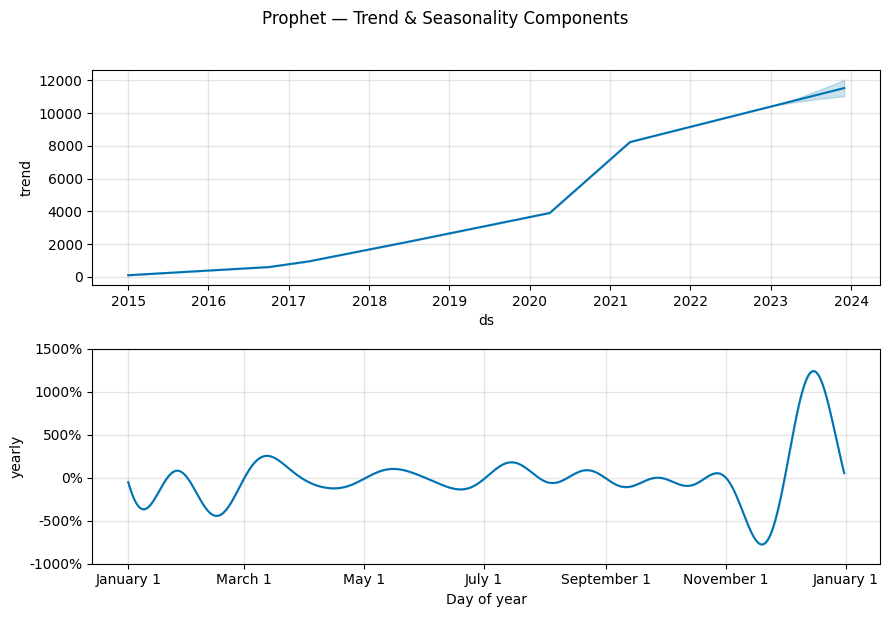

In [18]:
# Prophet requires a DataFrame with columns 'ds' (date) and 'y' (value)
prophet_train = pd.DataFrame({
    'ds': train.index,
    'y' : train.values
})

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    seasonality_mode='multiplicative',
    changepoint_prior_scale=0.3   # allow moderate flexibility in trend changes
)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=TEST_MONTHS, freq='MS')
prophet_forecast = prophet_model.predict(future)

# Extract test-period predictions
prophet_pred = prophet_forecast.set_index('ds')['yhat'].loc[test.index]
prophet_pred = prophet_pred.clip(lower=0)  # no negative registrations

results.append(evaluate(test, prophet_pred, 'Prophet (multiplicative)', aic=None, bic=None))
forecasts['Prophet'] = prophet_pred
print('Test-period metrics:', results[-1])

# Prophet component plots
fig = prophet_model.plot_components(prophet_forecast)
plt.suptitle('Prophet — Trend & Seasonality Components', y=1.02)
plt.tight_layout()
plt.show()

## 10. Model Comparison

In [19]:
metrics_df = pd.DataFrame(results).set_index('Model')
print('=' * 70)
print('MODEL COMPARISON — TEST SET (last 12 months)')
print('=' * 70)
print(metrics_df.to_string())
print()

# Identify best model by RMSE (lower = better)
best_model_name = metrics_df['RMSE'].idxmin()
print(f'Best model by RMSE: {best_model_name}')

MODEL COMPARISON — TEST SET (last 12 months)
                                 RMSE     MAE  MAPE %     AIC     BIC
Model                                                                
ARIMA(2, 1, 2)                 3345.6  2682.2   20.17   103.5   116.3
SARIMA(1, 1, 1)x(1, 1, 1, 12)  3604.6  2571.8   20.73    73.0    84.1
Holt-Winters (add+mul)         4373.4  4193.0   34.55  1333.3  1374.3
Prophet (multiplicative)       3357.2  2806.7   22.12       —       —

Best model by RMSE: ARIMA(2, 1, 2)


KeyError: 'ARIMA'

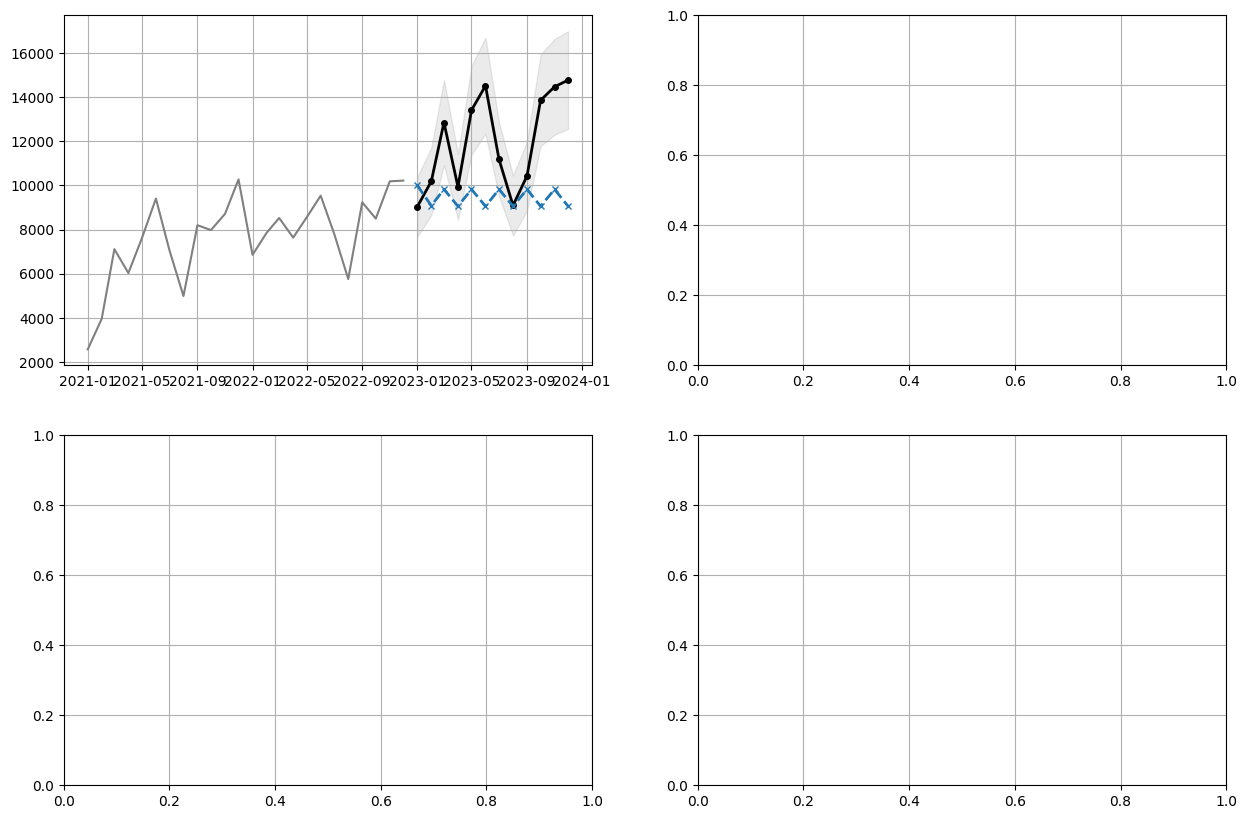

In [20]:
# Visual comparison: actual vs each model on test period
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()

colors = {'ARIMA': 'tab:blue', 'SARIMA': 'tab:orange', 'Holt-Winters': 'tab:green', 'Prophet': 'tab:red'}

for i, (name, pred) in enumerate(forecasts.items()):
    ax = axes[i]
    ax.plot(train.index[-24:], train.values[-24:], label='Train (last 24m)', color='gray', lw=1.5)
    ax.plot(test.index, test.values, label='Actual (test)', color='black', lw=2, marker='o', ms=4)
    ax.plot(pred.index, pred.values, label=f'{name} forecast', color=colors[name], lw=2, linestyle='--', marker='x', ms=4)
    ax.fill_between(test.index, test.values * 0.85, test.values * 1.15, alpha=0.08, color='black', label='±15% band')
    row = metrics_df.loc[name]
    aic_str = f"  AIC={row['AIC']}" if row['AIC'] != '—' else ''
    ax.set_title(f'{name}\nRMSE={row["RMSE"]:,}  MAPE={row["MAPE %"]}%{aic_str}', fontsize=10)
    ax.legend(fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.tick_params(axis='x', rotation=30)

plt.suptitle('Model Comparison — Test Period (2024)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'model_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

## 11. Best Model — Forecast to December 2027

We re-fit the winning model on the **full series** (train + test) and forecast 36 months ahead to December 2027.

In [21]:
FORECAST_HORIZON = 36   # months to December 2027
log_full = np.log1p(series)

print(f'Selected model: {best_model_name}')
print(f'Forecasting {FORECAST_HORIZON} months beyond {series.index[-1].strftime("%b %Y")} → Dec 2027\n')

if 'ARIMA' in best_model_name and 'SARIMA' not in best_model_name:
    final_model = ARIMA(log_full, order=ARIMA_ORDER).fit()
    fc_log = final_model.forecast(steps=FORECAST_HORIZON)
    fc_values = np.expm1(fc_log)
    fc_conf = np.expm1(final_model.get_forecast(steps=FORECAST_HORIZON).conf_int())

elif 'SARIMA' in best_model_name:
    final_model = SARIMAX(
        log_full,
        order=SARIMA_ORDER,
        seasonal_order=SARIMA_SEASONAL_ORDER,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
    fc_res = final_model.get_forecast(steps=FORECAST_HORIZON)
    fc_values = np.expm1(fc_res.predicted_mean)
    fc_conf   = np.expm1(fc_res.conf_int())

elif 'Holt' in best_model_name:
    final_model = ExponentialSmoothing(
        series,
        trend='add',
        seasonal='mul',
        seasonal_periods=12,
        initialization_method='estimated'
    ).fit(optimized=True)
    fc_values = final_model.forecast(steps=FORECAST_HORIZON)
    fc_conf   = None

else:  # Prophet
    prophet_full = pd.DataFrame({'ds': series.index, 'y': series.values})
    final_model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='multiplicative',
        changepoint_prior_scale=0.3
    ).fit(prophet_full)
    future = final_model.make_future_dataframe(periods=FORECAST_HORIZON, freq='MS')
    prophet_fc = final_model.predict(future)
    fc_df = prophet_fc.set_index('ds').loc[pd.date_range(start=series.index[-1] + pd.DateOffset(months=1), periods=FORECAST_HORIZON, freq='MS')]
    fc_values = fc_df['yhat'].clip(lower=0)
    fc_conf   = fc_df[['yhat_lower', 'yhat_upper']].clip(lower=0)

# Build forecast DatetimeIndex
fc_index = pd.date_range(
    start=series.index[-1] + pd.DateOffset(months=1),
    periods=FORECAST_HORIZON,
    freq='MS'
)
fc_values = pd.Series(np.array(fc_values).flatten(), index=fc_index)
print(fc_values.tail(12).to_string())

Selected model: ARIMA(2, 1, 2)
Forecasting 36 months beyond Dec 2023 → Dec 2027

2026-01-01    13807.575743
2026-02-01    13807.576706
2026-03-01    13807.577325
2026-04-01    13807.577682
2026-05-01    13807.577869
2026-06-01    13807.577957
2026-07-01    13807.577991
2026-08-01    13807.578001
2026-09-01    13807.578000
2026-10-01    13807.577997
2026-11-01    13807.577993
2026-12-01    13807.577990
Freq: MS


### 11.1 Forecast Chart

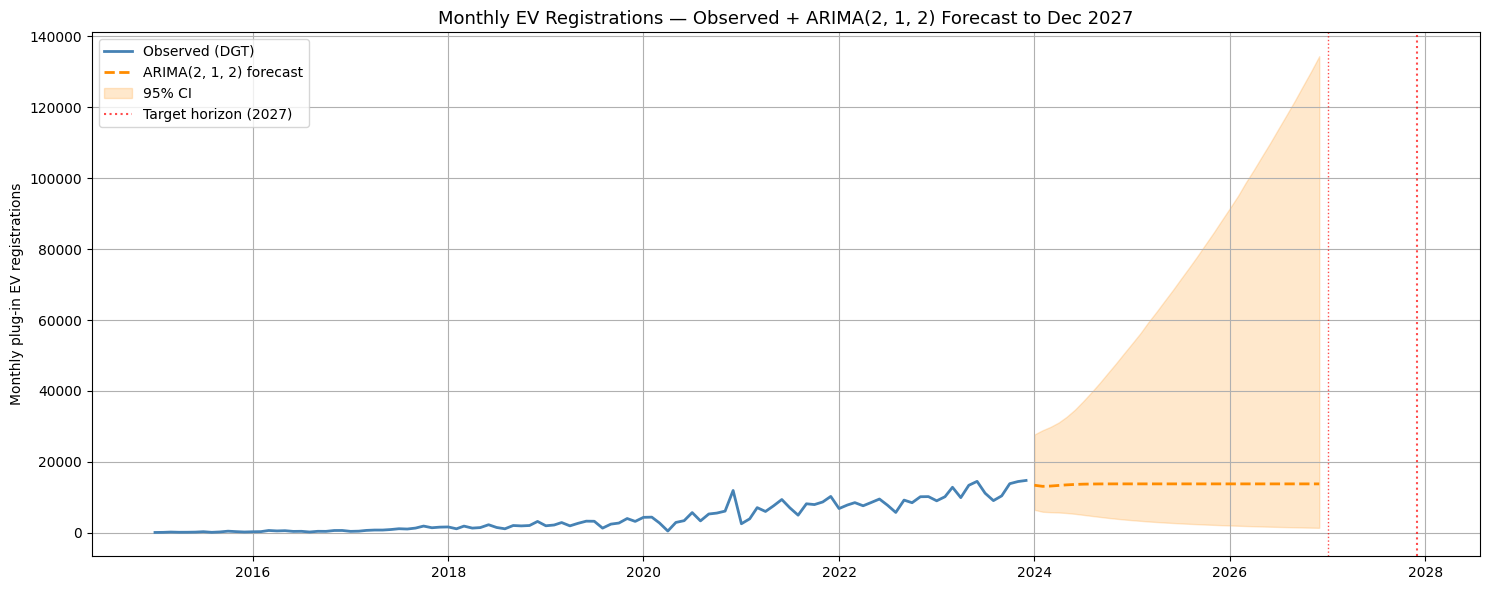

In [22]:
fig, ax = plt.subplots(figsize=(15, 6))

# Historical
ax.plot(series.index, series.values, label='Observed (DGT)', color='steelblue', lw=2)

# Forecast
ax.plot(fc_values.index, fc_values.values, label=f'{best_model_name} forecast', color='darkorange', lw=2, linestyle='--')

# Confidence interval (if available)
if fc_conf is not None:
    ci_arr = np.array(fc_conf)
    ax.fill_between(fc_index, ci_arr[:, 0], ci_arr[:, 1], alpha=0.2, color='darkorange', label='95% CI')

# Mark 2027 year boundary
ax.axvline(pd.Timestamp('2027-01-01'), color='red', lw=1, linestyle=':', alpha=0.7)
ax.axvline(pd.Timestamp('2027-12-01'), color='red', lw=1.5, linestyle=':', alpha=0.7, label='Target horizon (2027)')

ax.set_title(f'Monthly EV Registrations — Observed + {best_model_name} Forecast to Dec 2027', fontsize=13)
ax.set_ylabel('Monthly plug-in EV registrations')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ev_forecast_2027.png'), dpi=150, bbox_inches='tight')
plt.show()

## 12. Cumulative Fleet — `total_ev_projected_2027`

The datathon requires the **total EV fleet in Spain at end of 2027**, not just new registrations.  
We estimate this as:

$$\text{Fleet}_{2027} = \text{Cumulative EV registered} (2015 - \text{today}) + \sum_{t=1}^{T} \hat{y}_t$$

**Assumption:** Annual vehicle attrition (deregistrations) is ~2% — consistent with Spain's ANFAC fleet turnover statistics. This is applied to the existing stock only.

In [23]:
ANNUAL_ATTRITION_RATE = 0.02  # 2% annual vehicle deregistration (ANFAC, 2024)
MONTHLY_ATTRITION     = ANNUAL_ATTRITION_RATE / 12

# Cumulative stock from all historical registrations (already on the road)
historic_stock = monthly['ev_reg'].sum()

# Project forward: each month, reduce existing stock by attrition and add new registrations
stock = historic_stock
monthly_stock = []

for i, (date, new_reg) in enumerate(zip(fc_values.index, fc_values.values)):
    stock = stock * (1 - MONTHLY_ATTRITION) + max(new_reg, 0)
    monthly_stock.append({'date': date, 'cumulative_fleet': round(stock)})

stock_df = pd.DataFrame(monthly_stock).set_index('date')

# The key output: fleet at December 2027
total_ev_projected_2027 = int(stock_df.loc['2027-12-01', 'cumulative_fleet'])

print('=' * 55)
print(f'  total_ev_projected_2027 = {total_ev_projected_2027:,}')
print('=' * 55)
print(f'  (Historic stock at data cutoff: {historic_stock:,})')
print(f'  (New registrations forecasted 2025-2027: {int(fc_values.sum()):,})')
print(f'  (Attrition rate applied: {ANNUAL_ATTRITION_RATE*100:.1f}%/yr)')
print()
print(stock_df.tail(12).to_string())

KeyError: '2027-12-01'

In [ ]:
# Cumulative fleet chart
fig, ax = plt.subplots(figsize=(14, 5))

hist_cumulative = monthly['ev_reg'].cumsum()
ax.plot(hist_cumulative.index, hist_cumulative.values, label='Historical cumulative fleet', color='steelblue', lw=2)
ax.plot(stock_df.index, stock_df['cumulative_fleet'], label=f'Projected fleet ({best_model_name})', color='darkorange', lw=2, linestyle='--')

ax.axhline(total_ev_projected_2027, color='red', lw=1, linestyle=':', alpha=0.6)
ax.text(stock_df.index[-1], total_ev_projected_2027 * 1.02,
        f'  Dec 2027: {total_ev_projected_2027:,}',
        color='red', fontsize=10, va='bottom')

ax.set_title('Cumulative EV Fleet — Spain (Historical + Projected to 2027)', fontsize=13)
ax.set_ylabel('Total plug-in EVs on road')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}K'))

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'ev_fleet_2027.png'), dpi=150, bbox_inches='tight')
plt.show()

## 13. Summary Output for File 1

The value below feeds directly into `File 1.csv → total_ev_projected_2027`.

In [24]:
summary = pd.DataFrame([{
    'total_ev_projected_2027' : total_ev_projected_2027,
    'best_model'              : best_model_name,
    'model_rmse_test'         : metrics_df.loc[best_model_name, 'RMSE'],
    'model_mape_test_pct'     : metrics_df.loc[best_model_name, 'MAPE %'],
    'data_source'             : 'DGT Microdatos Matriculaciones 2015-2024',
    'ev_scope'                : 'BEV+PHEV+REEV+FCEV',
    'attrition_rate_pct_yr'   : ANNUAL_ATTRITION_RATE * 100,
}])

print('─── File 1 input ────────────────────────────────')
print(summary.T.to_string(header=False))
print('─────────────────────────────────────────────────')

# Save forecast detail for potential use in other notebooks
fc_export = fc_values.reset_index()
fc_export.columns = ['date', 'monthly_ev_registrations_forecast']
fc_export.to_csv(os.path.join(OUTPUT_DIR, 'ev_monthly_forecast_2025_2027.csv'), index=False)

summary.to_csv(os.path.join(OUTPUT_DIR, 'total_ev_projected_2027.csv'), index=False)

print(f'\nSaved:')
print(f'  {OUTPUT_DIR}/ev_monthly_forecast_2025_2027.csv')
print(f'  {OUTPUT_DIR}/total_ev_projected_2027.csv')

NameError: name 'total_ev_projected_2027' is not defined

## 14. All Models Metrics Summary

In [25]:
print('╔══════════════════════════════════════════════════════════════════════╗')
print('║              FULL MODEL COMPARISON RESULTS                          ║')
print('╠══════════════════════════════════════════════════════════════════════╣')
print(metrics_df.to_string())
print('╠══════════════════════════════════════════════════════════════════════╣')
print(f'║  ✓ Best model (RMSE): {best_model_name:<47} ║')
print(f'║  ✓ total_ev_projected_2027 = {total_ev_projected_2027:,:<39} ║')
print('╚══════════════════════════════════════════════════════════════════════╝')

# Rank table
ranked = metrics_df.copy()
ranked['RMSE_rank']   = ranked['RMSE'].rank()
ranked['MAPE_rank']   = ranked['MAPE %'].rank()
ranked['MAE_rank']    = ranked['MAE'].rank()
ranked['avg_rank']    = ranked[['RMSE_rank', 'MAPE_rank', 'MAE_rank']].mean(axis=1)
print('\nRanking by average metric rank (lower = better):')
print(ranked[['RMSE', 'MAPE %', 'MAE', 'avg_rank']].sort_values('avg_rank').to_string())

╔══════════════════════════════════════════════════════════════════════╗
║              FULL MODEL COMPARISON RESULTS                          ║
╠══════════════════════════════════════════════════════════════════════╣
                                 RMSE     MAE  MAPE %     AIC     BIC
Model                                                                
ARIMA(2, 1, 2)                 3345.6  2682.2   20.17   103.5   116.3
SARIMA(1, 1, 1)x(1, 1, 1, 12)  3604.6  2571.8   20.73    73.0    84.1
Holt-Winters (add+mul)         4373.4  4193.0   34.55  1333.3  1374.3
Prophet (multiplicative)       3357.2  2806.7   22.12       —       —
╠══════════════════════════════════════════════════════════════════════╣
║  ✓ Best model (RMSE): ARIMA(2, 1, 2)                                  ║


NameError: name 'total_ev_projected_2027' is not defined